In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import graph_delineator.delineate_reservoirs as dr

# 1. Define Inputs
merit_dirs = {
    'basins': Path('/nas/cee-ice/data/MERIT'),
    'flow_dir': Path('/nas/cee-ice/data/MERIT-Hydro/processed/dir/'),
    'flow_acc': Path('/nas/cee-ice/data/MERIT-Hydro/processed/upg/')
}

# Use local demo gauges
gauges_path = Path('demo/demo.csv').resolve()

# Reservoir GDB
gdb_path = '/work/pi_casey_umass_edu/Owen/Reservoirs/LakeSPvC_ts_for_Ted/SWOT_PLD_v106_reservoirs.gdb'

In [ ]:
# 2. Load Reservoirs (Clipped)
print("Reading reservoirs based on gauge extent...")
gauges_df = pd.read_csv(gauges_path)
# Create a buffer around gauges to catch reservoirs in the basin
bbox = (
    gauges_df.lng.min() - 0.5, 
    gauges_df.lat.min() - 0.5, 
    gauges_df.lng.max() + 0.5, 
    gauges_df.lat.max() + 0.5
)


reservoirs = gpd.read_file(gdb_path, bbox=bbox)
print(f"Loaded {len(reservoirs)} reservoirs in the bounding box.")


Reading reservoirs based on gauge extent...
Loaded 1398 reservoirs in the bounding box.


/work/pi_casey_umass_edu/Owen/graph_delineator/.venv/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Running delineation... Output: /work/pi_casey_umass_edu/Owen/graph_delineator/demo/validation_output
Filtered reservoirs by area >= 0.2 km2: 1398 -> 331

GRAPH-BASED WATERSHED DELINEATION
Data output directory: /work/pi_casey_umass_edu/Owen/graph_delineator/demo/validation_output
Loaded 128 gauges total.
Skipping 0 already processed outlets.
Processing 128 remaining gauges.


Basin 7:   0%|          | 0/1 [00:00<?, ?it/s]

  Reservoir 7310030152: merged 1 nodes into 7310030152
  Reservoir 7310031052: merged 1 nodes into 7310031052
  Reservoir 7310031422: merged 1 nodes into 7310031422
  Reservoir 7310031472: merged 1 nodes into 7310031472
  Reservoir 7310031793: merged 1 nodes into 7310031793
  Reservoir 7310031822: merged 1 nodes into 7310031822
  Reservoir 7310032282: merged 1 nodes into 7310032282
  Reservoir 7310032672: merged 1 nodes into 7310032672
  Reservoir 7310032772: merged 1 nodes into 7310032772
  Reservoir 7310033072: merged 1 nodes into 7310033072
  Reservoir 7310033722: merged 1 nodes into 7310033722
  Reservoir 7310034092: merged 1 nodes into 7310034092
  Reservoir 7310034162: merged 1 nodes into 7310034162
  Reservoir 7310034212: merged 0 nodes into 7310034212
  Reservoir 7310034532: merged 1 nodes into 7310034532
  Reservoir 7310034693: merged 1 nodes into 7310034693
  Reservoir 7310034712: merged 1 nodes into 7310034712
  Reservoir 7310034842: merged 1 nodes into 7310034842
  Reservoi

Basin 7: 100%|██████████| 1/1 [00:35<00:00, 35.52s/it]



DELINEATION SUMMARY
  Outlet USGS-01578310: 128 Gauges, 89 Reservoirs, 76 Catchment/Other Nodes
COMPLETE
Delineation complete.


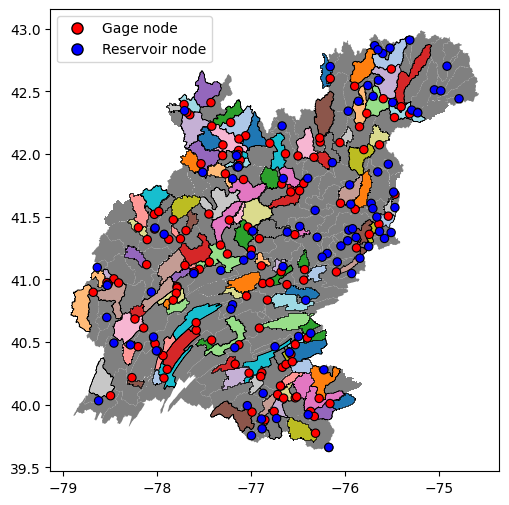

In [ ]:
# 3. Run Delineation with Traceback
output_dir = Path('demo/validation_output').resolve()

print(f"Running delineation... Output: {output_dir}")
try:
    results = dr.delineate_basins(
        gauges_path=gauges_path,
        merit_dirs=merit_dirs,
        reservoirs=reservoirs,        min_reserv=hlhllxfsdfddv hghhhh`
        max_area=500,
        output_dir=output_dir,
        save_plots=True,
        consolidate=True,
        overwrite=True
    )
    print("Delineation complete.")
except Exception as e:
    import traceback
    print(f"Delineation failed: {e}")
    print(traceback.format_exc())m

In [4]:
# 4. List Available Subbasins
global_subbasins = None
global_gauges = None
global_reservoirs = reservoirs if 'reservoirs' in locals() else None

if 'results' in locals() and results:
    # Grab the first result (assuming one basin for demo)
    # Note: results dict might be empty if Delineation failed partially but returned {}
    if len(results) > 0:
        outlet, result = list(results.items())[0]
        print(f"Using Results from Basin Outlet: {outlet}")
        
        # Now returns 3 dataframes: subbasins, gauges, rivers
        global_subbasins, global_gauges = result.to_geodataframes()
        
        print(f"\nAvailable Subbasins ({len(global_subbasins)} total):")
        print(global_subbasins['id'].tolist())
        
        if 'is_reservoir' in global_subbasins.columns:
            res_only = global_subbasins[global_subbasins['is_reservoir'] == True]
            print(f"\nReservoir Subbasins ({len(res_only)}):")
            print(res_only['id'].tolist())
    else:
        print("Results dictionary is empty.")
else:
    print("No results available to list.")

Using Results from Basin Outlet: USGS-01578310

Available Subbasins (293 total):
['73006156', '73006008', '73005555', '73005544', '73005534', '73003655', '73005494', '73002027', '73005476', '73005457', '73001995', '73003603', '73005447', '73005444', '73005440', '73005438', '73005433', '73003575', '73005417', '73003553', '73003544', '73005401', '73001949', '73003508', '73005368', '73005355', '73005346', '73003463', '73003448', '73005325', '73005318', '73005313', '73003417', '73005296', '73005284', '73005280', '73003337', '73003248', '73005128', '73005127', '73005124', '73005122', '73005121', '73005117', '73005115', '73005110', '73005100', '73003223', '73005091', '73003215', '73003214', '73003151', '73003150', '73003149', '73003131', '73003120', '73003115', '73003112', '73003107', '73003105', '73003099', '73003098', '73003096', '73003092', '73003079', '73003069', '73003065', '73003061', '73003057', '73003052', '73003047', '73003035', '73003031', '73003030', '73005201', '73002979', 'USGS-

Plotting 7310031052...
Loading rivers from riv_pfaf_7_MERIT_Hydro_v07_Basins_v01_bugfix1.shp for bbox...


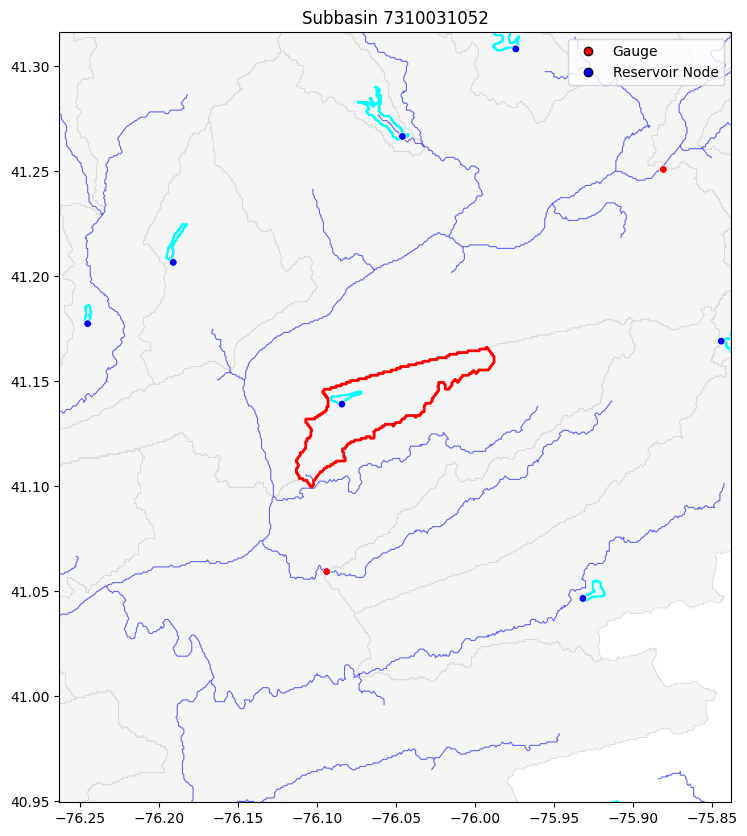

In [6]:
# 6. Interactive Subbasin Plot (User Request)
target_id = "7310031052"

if target_id and global_subbasins is not None and target_id in global_subbasins['id'].values:
    print(f"Plotting {target_id}...")
    
    # 1. Get Bounds
    target_row = global_subbasins[global_subbasins['id'] == target_id]
    bounds = target_row.total_bounds
    buffer = 0.15
    xlim = (bounds[0] - buffer, bounds[2] + buffer)
    ylim = (bounds[1] - buffer, bounds[3] + buffer)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 2. Plot Streamlines (Efficient Load)
    try:
        # Use only the FIRST digit for the major basin file
        major_basin_id = int(str(target_id)[0])
        
        # Construct filename (e.g., riv_pfaf_7_...)
        riv_file = merit_dirs['basins'] / f"riv_pfaf_{major_basin_id}_MERIT_Hydro_v07_Basins_v01_bugfix1.shp"
        
        if riv_file.exists():
            print(f"Loading rivers from {riv_file.name} for bbox...")
            
            # Efficiently read ONLY the data in the view window
            # This is much faster than reading the whole file and then clipping
            riv = gpd.read_file(riv_file, bbox=(xlim[0], ylim[0], xlim[1], ylim[1]))
            
            if not riv.empty:
                riv.plot(ax=ax, linewidth=0.8, color='blue', alpha=0.6, label='Streamlines', zorder=1)
            else:
                print("No rivers found in this view extent.")
        else:
             print(f"River file not found: {riv_file}")
             
    except Exception as e:
         print(f"Could not load rivers: {e}")

    # 3. Plot Reservoirs (> 0.2 km2)
    if global_reservoirs is not None:
        res_subset = global_reservoirs.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]].copy()
        if not res_subset.empty:
            if 'area_geodesic_km2' in res_subset.columns:
                large_res = res_subset[res_subset['area_geodesic_km2'] > 0.2]
                if not large_res.empty:
                     large_res.plot(ax=ax, facecolor='none', edgecolor='cyan', linewidth=1.5, label='Reservoirs > 0.2km2', zorder=2)
            else:
                res_subset.plot(ax=ax, facecolor='none', edgecolor='cyan', linewidth=1, linestyle='--', zorder=2)

    # 4. Plot Target Subbasin
    target_row.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label=f'Subbasin {target_id}', zorder=3)
    
    # 5. Background Subbasins
    global_subbasins.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]].plot(ax=ax, facecolor='whitesmoke', edgecolor='lightgrey', linewidth=0.5, zorder=0)

    # 6. Plot Nodes (Gauges=Red, Reservoirs=Blue, Others=Black)
    # Filter nodes to view extent
    if 'geometry' in global_subbasins.columns:
        # Assuming global_subbasins contains the node info since we merged outputs
        # OR if you have a separate 'global_nodes' dataframe from save_result, use that.
        # But based on typical usage, let's use global_subbasins centroid or if you have a nodes DF
        
        # If you have global_gauges (which is now global_nodes from the update):
        nodes_subset = global_gauges.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]].copy()
        
        if not nodes_subset.empty:
            # Color logic
            colors = []
            for _, row in nodes_subset.iterrows():
                if row.get('is_gauge', False):
                    colors.append('red')
                elif row.get('is_reservoir', False):
                    colors.append('blue')
                else:
                    colors.append('black')
            
            nodes_subset.plot(ax=ax, color=colors, markersize=30, edgecolor='white', linewidth=0.5, zorder=5)
            
            # Add proxy artists for legend
            from matplotlib.lines import Line2D
            handles = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Gauge', markeredgecolor='k'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Reservoir Node', markeredgecolor='k')
            ]
            ax.legend(handles=handles, loc='upper right')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    plt.title(f"Subbasin {target_id}")
    plt.show()
else:
    print("Subbasin ID not found or data not loaded.")